<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
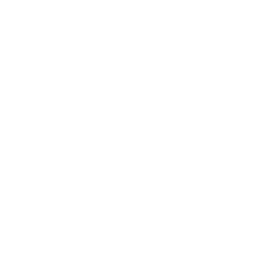
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Αναγνώριση Καθεστώτων Αγοράς</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ποσοτική Χρηματοοικονομική / Διαχείριση Περιουσιακών Στοιχείων &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη

Αυτό το παράδειγμα χρησιμοποιεί την **PROC ACECLUS** για να εντοπίσει τη λανθάνουσα δομή που διαχωρίζει τα καθεστώτα της αγοράς και στη συνέχεια εφαρμόζει συσταδοποίηση πάνω σε αυτήν. Από 100 εβδομαδιαίες παρατηρήσεις 10 χαρακτηριστικών της αγοράς (απόδοση και μεταβλητότητα μετοχών, πιστωτικά περιθώρια και περιθώρια υψηλής απόδοσης, την καμπύλη 2y/10y, το δολάριο, τα εμπορεύματα και μια μεταβολή του VIX), η ACECLUS εκτιμά μια προσεγγιστική εντός-καθεστώτος συνδιακύμανση *χωρίς* να χρησιμοποιεί καμία ετικέτα καθεστώτος και εξάγει κανονικές μεταβλητές κατά μήκος των οποίων τα καθεστώτα διαχωρίζονται.

Στο κατώφλι P=0.02 ο αλγόριθμος συγκλίνει σε δύο επαναλήψεις και διατηρεί **τρεις κανονικές διαστάσεις**, οι οποίες μαζί εξηγούν όλη τη διασπορά μεταξύ των καθεστώτων (αναλογίες ιδιοτιμών 57.8%, 24.4%, 17.8%). Ένα πιο χαλαρό κατώφλι P=0.05 υπερεξομαλύνει τη συνδιακύμανση και **καταρρέει τη δομή σε μία μόνο διάσταση** — μια χρήσιμη προειδοποίηση ότι το κατώφλι διαμορφώνει ουσιαστικά το αποτέλεσμα.

Η τροφοδότηση των τριών κανονικών μεταβλητών στην **PROC FASTCLUS** (k=4) δίνει μια καθαρή ταξινόμηση των 100 εβδομάδων κατά σοβαρότητα πίεσης (συνολικό R² = 0.51, pseudo F = 33.2): έναν ήρεμο πυρήνα 62 εβδομάδων, μια ομάδα 22 εβδομάδων σε ανάκαμψη/με υποχωρούσα μεταβλητότητα, μια ομάδα 12 εβδομάδων αυξημένης πίεσης και μια ομάδα 4 εβδομάδων βαθιάς κρίσης με περιθώρια υψηλής απόδοσης κατά μέσο όρο ~1.514 bps. Αυτές οι αναθέσεις εξάγονται για την επακόλουθη προσαρμογή του κινδύνου χαρτοφυλακίου.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Εβδομαδιαίες παρατηρήσεις χαρακτηριστικών της αγοράς σε όλες τις κατηγορίες περιουσιακών στοιχείων | 100 |
| Μεταβλητές: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Η σειρά παράγεται από μια διαδικασία εναλλαγής καθεστώτων Markov πέντε καταστάσεων (ανοδική επέκταση, όψιμος κύκλος, risk-off, κρίση, ανάκαμψη) με κατανομές χαρακτηριστικών εξαρτώμενες από το καθεστώς. Κατά την εκτέλεση χωρίς άδεια, ο πίνακας χαρακτηριστικών περιορίζεται στις πρώτες 100 εβδομαδιαίες παρατηρήσεις (~2 έτη) — ένα παράθυρο με κυριαρχία ανοδικής αγοράς που επισκέπτεται επίσης μια σύντομη κρίση και ανάκαμψη. Οι εβδομαδιαίες αποδόσεις και οι μεταβολές επιπέδου αντικαθιστούν τις κινήσεις τιμών στο τέλος της εβδομάδας· τα περιθώρια είναι σε μονάδες βάσης και η μεταβλητότητα είναι ένας δείκτης τύπου VIX.


---

In [1]:
/* --------------------------------------------------------
   Dimiourgia evdomadiaias polyperiousiakis istorias agoras
   me pente enswmatwmena kathestwta poy odigountai apo
   diadikasia Markov. To paradeigma trechei achoris adeia,
   opote o pinakas periorizetai stis protes 100 evdomades.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.market_weekly;
    CALL streaminit(42);
    LENGTH regime_label $32;
    /* 5 kathestwta */
    ARRAY regime_names[5] $32 _temporary_
        ('Αγορά Ανόδου' 'Ύστερος Κύκλος' 'Αποφυγή Κινδύνου'
         'Κρίση' 'Ανάκαμψη');
    RETAIN current_regime 1;
    ΕΠΑΝΑΛΗΨΗ week_id = 1 ΕΩΣ 5000;
        /* Markov regime switching */
        u = rand('uniform');
        ΕΑΝ current_regime = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ u > 0.97 ΤΟΤΕ current_regime = 2;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 2 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ u > 0.92 ΤΟΤΕ current_regime = 3;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 3 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ u > 0.80 ΤΟΤΕ current_regime = 4;
            ΑΛΛΙΩΣ ΕΑΝ u < 0.10 ΤΟΤΕ current_regime = 1;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 4 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ u > 0.75 ΤΟΤΕ current_regime = 5;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 5 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ u > 0.85 ΤΟΤΕ current_regime = 1;
        ΤΕΛΟΣ;
        regime_label = regime_names[current_regime];
        /* Regime-conditional feature distributions */
        ΕΑΝ current_regime = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 2 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 3 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ current_regime = 4 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        ΤΕΛΟΣ;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        ΕΑΝ week_id = 1 ΤΟΤΕ vix_chg = 0;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ u;
    RENAME credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.34 seconds
  cpu   1.34 seconds


---

In [2]:
/* Katanomes charaktiristikwn agoras ana kathestws */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.market_weekly n mean std MIN MAX;
    ΚΛΑΣΗ regime_label;
    ΜΕΤΑΒΛΗΤΗ eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ΕΤΙΚΕΤΑ regime_label="Καθεστώς αγοράς"
          eq_return_pct="Εβδομαδιαία απόδοση μετοχών (%)"
          eq_vol_idx="Δείκτης μεταβλητότητας μετοχών"
          credit_spread_bps="Πιστωτικό spread (μ.β.)"
          hy_spread_bps="Spread υψηλής απόδοσης (μ.β.)"
          term_spread="Spread διάρκειας"
          vix_chg="Μεταβολή VIX";
    TITLE "Κατανομές χαρακτηριστικών αγοράς ανά καθεστώς";
ΕΚΤΕΛΕΣΗ;

                                     Κατανομές χαρακτηριστικών αγοράς ανά καθεστώς                                      

                                                  The MEANS Procedure

               Analysis Variable : eq_return_pct Εβδομαδιαία απόδοση μετοχών (%)

        Καθεστώς αγοράς                        N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------
        Ύστερος                                   39      0.0364359      1.9733801     -4.6010000      3.7030000
        Αγορά                                     28      0.2860000      1.0226518     -1.5980000      2.2150000
        Ανάκ                                       4      0.0077500      1.5951747     -0.8330000      2.4000000
        Αποφυγή                                   17     -0.8447059      1.2832441     -3.3850000      1.1810000
        Κρ                                     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                     Κατανομές χαρακτηριστικών αγοράς ανά καθεστώς                                      




NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


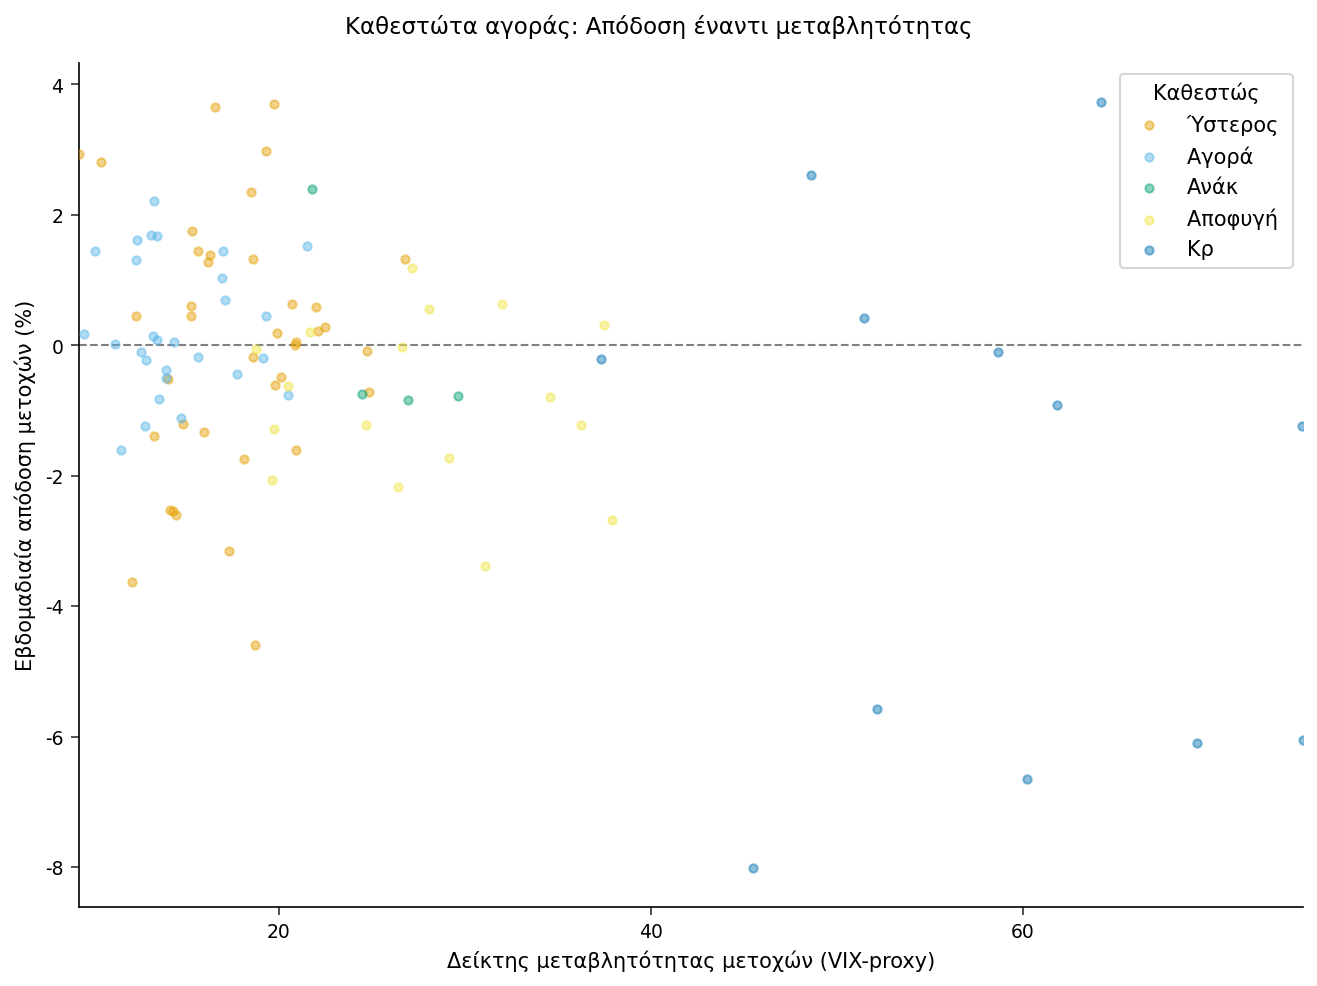

In [3]:
/* Apodosi metochwn enanti deikti metavlitotitas ana kathestws */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ΕΤΙΚΕΤΑ="Δείκτης μεταβλητότητας μετοχών (VIX-proxy)";
    YAXIS ΕΤΙΚΕΤΑ="Εβδομαδιαία απόδοση μετοχών (%)";
    keylegend / TITLE="Καθεστώς";
    TITLE "Καθεστώτα αγοράς: Απόδοση έναντι μεταβλητότητας";
ΕΚΤΕΛΕΣΗ;

---

In [4]:
/* Prosengistiki ektimisi endo-kathestwtos syndiakymansis me ACECLUS. */
ΔΙΑΔΙΚΑΣΙΑ aceclus ΔΕΔΟΜΕΝΑ=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    ΜΕΤΑΒΛΗΤΗ eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    TITLE "Κανονικές μεταβλητές ACECLUS (P=0.02)";
ΕΚΤΕΛΕΣΗ;

                                     Κατανομές χαρακτηριστικών αγοράς ανά καθεστώς                                      

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* Elenchos evaisthisias se P=0.05 -- chalarotero katwfli. */
ΔΙΑΔΙΚΑΣΙΑ aceclus ΔΕΔΟΜΕΝΑ=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    ΜΕΤΑΒΛΗΤΗ eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    TITLE "Κανονικές μεταβλητές ACECLUS (P=0.05)";
ΕΚΤΕΛΕΣΗ;

                                     Κατανομές χαρακτηριστικών αγοράς ανά καθεστώς                                      

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* k-means stis kanonikes metavlites ACECLUS. */
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    ΜΕΤΑΒΛΗΤΗ can1 can2 can3;
    TITLE "Ομαδοποίηση k-means σε κανονικές μεταβλητές";
ΕΚΤΕΛΕΣΗ;

                                     Κατανομές χαρακτηριστικών αγοράς ανά καθεστώς                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                    Συστάδα καθεστώτος έναντι πραγματικού καθεστώτος                                    

                                                   The FREQ Procedure

Table of Συστάδα by Καθεστώς αγοράς

Συστάδα        |        Ύστερος |         Αγορά  |           Ανάκ |       Αποφυγή  |             Κρ |           Total
---------------+----------------+----------------+----------------+----------------+----------------+----------------
1              |              2 |              2 |              0 |              4 |              4 |              12
               |           2.00 |           2.00 |           0.00 |           4.00 |           4.00 |           12.00
---------------+----------------+----------------+----------------+----------------+----------------+----------------
2              |             28 |             21 |              3 |              7 |              3 |              62
               |          28.00 |          21.00 |           3


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


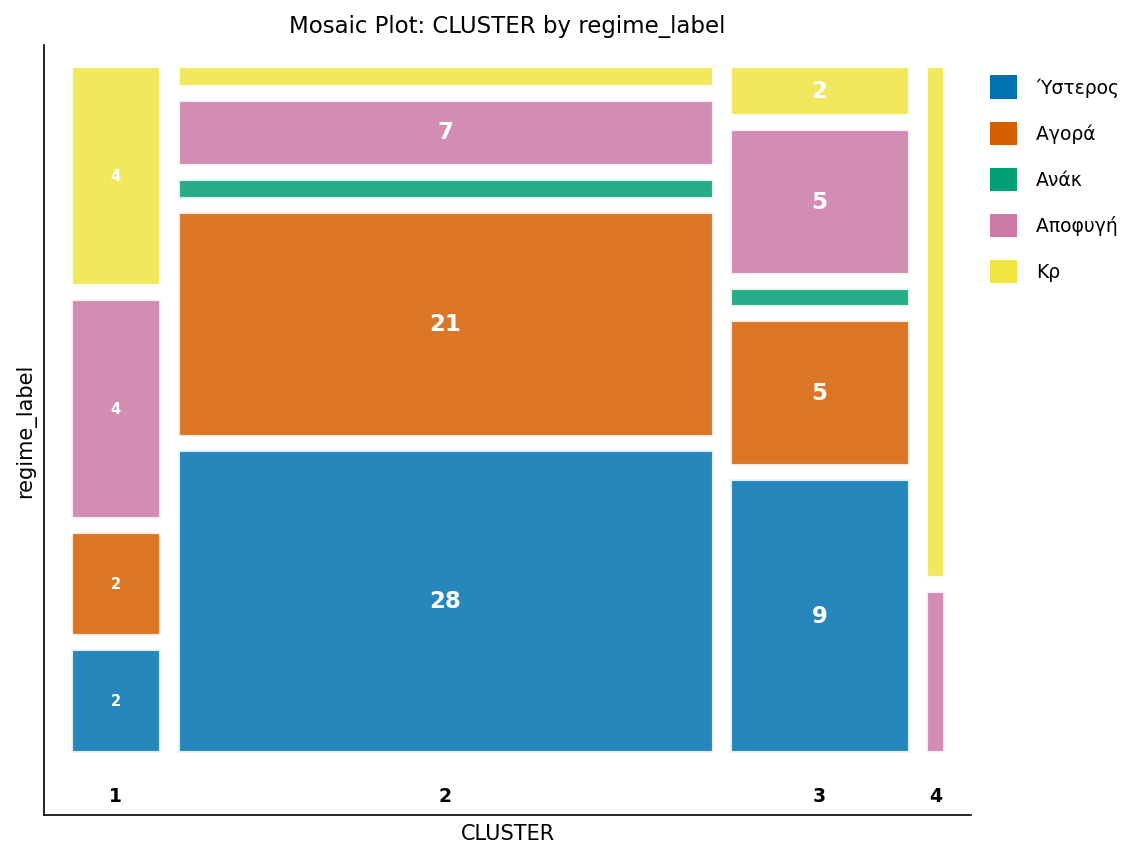

In [7]:
/* Epalithefsi anatethimenwn systadwn enanti gnwstwn kathestwtwn */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    ΕΤΙΚΕΤΑ CLUSTER="Συστάδα" regime_label="Καθεστώς αγοράς";
    TITLE "Συστάδα καθεστώτος έναντι πραγματικού καθεστώτος";
ΕΚΤΕΛΕΣΗ;

In [8]:
/* Profil meswn timwn charaktiristikwn ana systada */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.regime_assignments mean;
    ΚΛΑΣΗ CLUSTER;
    ΜΕΤΑΒΛΗΤΗ eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ΕΤΙΚΕΤΑ CLUSTER="Συστάδα"
          eq_return_pct="Εβδομαδιαία απόδοση μετοχών (%)"
          eq_vol_idx="Δείκτης μεταβλητότητας μετοχών"
          credit_spread_bps="Πιστωτικό spread (μ.β.)"
          hy_spread_bps="Spread υψηλής απόδοσης (μ.β.)"
          term_spread="Spread διάρκειας"
          vix_chg="Μεταβολή VIX";
    TITLE "Μέσες τιμές χαρακτηριστικών ανά συστάδα";
ΕΚΤΕΛΕΣΗ;

                                        Μέσες τιμές χαρακτηριστικών ανά συστάδα                                         

                                                  The MEANS Procedure

                                         Analysis Variable : eq_return_pct Εβδομαδιαία απόδοση μετοχών (%)

                                                             N
                                         Συστάδα           Obs            Mean
                                         -------------------------------------
                                         1                  12      -2.0955000
                                         2                  62      -0.3638871
                                         3                  22       0.7421364
                                         4                   4      -0.4010000
                                         -------------------------------------

                                         Analysis Variable : eq_vol_idx Δείκτης με


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Ερμηνεία

**Κανονική δομή ACECLUS.** Στο δείγμα των 100 εβδομάδων, η PROC ACECLUS (P=0.02, κατώφλι = 2.578941) συνέκλινε σε δύο επαναλήψεις και παρήγαγε τρεις κανονικές μεταβλητές. Οι ιδιοτιμές τους του `Inv(ACE)*(COV-ACE)` είναι 0.0219, 0.0093 και 0.0067, δηλαδή αναλογίες 57.8%, 24.4% και 17.8% (αθροιστικά 100%). Ο πρώτος κανονικός άξονας φέρει την κυρίαρχη αντίθεση risk-on/risk-off· ο δεύτερος και ο τρίτος την εκλεπτύνουν. Επειδή τα χαρακτηριστικά μεταβλητότητας μετοχών και περιθωρίων συγκινούνται έντονα, η ACECLUS ενσωματώνει αυτή την κοινή διακύμανση στην εντός-καθεστώτος συνδιακύμανση, ώστε οι κανονικοί άξονες να αντικατοπτρίζουν πραγματικό διαχωρισμό μεταξύ καθεστώτων παρά κοινή κλίμακα.

**Ευαισθησία κατωφλίου.** Η επανεκτέλεση με P=0.05 ανεβάζει το κατώφλι απόστασης στο 2.899704, το οποίο τραβά 4.949 από τα 4.950 ζεύγη παρατηρήσεων εντός του ορίου. Η εκτιμώμενη εντός-καθεστώτος συνδιακύμανση τότε σχεδόν ισούται με τη συνολική συνδιακύμανση, και η κανονική δομή **καταρρέει σε μία μόνο διάσταση** (μία ιδιοτιμή, 0.0096, στο 100%). Οι λύσεις P=0.02 και P=0.05 επομένως *δεν* είναι εναλλάξιμες εδώ — ένα πιο χαλαρό κατώφλι διαγράφει τους λεπτότερους άξονες καθεστώτος, οπότε το στενότερο κατώφλι είναι η πιο ενημερωτική προδιαγραφή για αυτό το δείγμα.

**Συσταδοποίηση στις κανονικές μεταβλητές.** Η PROC FASTCLUS (k=4) στις Can1–Can3 δίνει συνολικό R² 0.5089 και pseudo F 33.16. Η Can2 κάνει το μεγαλύτερο μέρος του διαχωριστικού έργου (R² = 0.626), η Can1 συνεισφέρει μέτρια (R² = 0.359), και η Can3 δεν προσθέτει ουσιαστικά τίποτα (R² = 0.000) — σε συμφωνία με το ότι μόνο δύο άξονες φέρουν ισχυρό σήμα. Οι τέσσερις συστάδες παρατάσσονται ως μια διαβάθμιση πίεσης της αγοράς:

| Συστάδα | n | Μέση Απόδοση Μετοχών | Μέσο VIX | Μέσο Περιθώριο HY | Μέση Μεταβολή VIX | Ανάγνωση |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Ήρεμος πυρήνας (ανοδική / όψιμος κύκλος) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Σε ανάκαμψη, μεταβλητότητα υποχωρεί |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Αυξημένη πίεση, μεταβλητότητα εκτινάσσεται |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Βαθιά κρίση, ακραία πιστωτική πίεση |

**Συστάδα έναντι πραγματικού καθεστώτος.** Ο διασταυρωμένος πίνακας δείχνει ότι οι συστάδες δεν αντιστοιχίζονται ένα-προς-ένα στις πέντε ετικέτες παραγωγής — αναμενόμενο, επειδή οι ετικέτες επικαλύπτονται έντονα στον χώρο χαρακτηριστικών σε αυτό το μέγεθος δείγματος. Η μεγάλη ήρεμη συστάδα (62) απορροφά τις περισσότερες ανοδικές (21) και όψιμου κύκλου (28) εβδομάδες· η συστάδα βαθιάς κρίσης (4) αποτελείται σχεδόν εξ ολοκλήρου από τις πιο ακραίες εβδομάδες κρίσης (3 από 4). Οι κανονικοί άξονες έτσι οργανώνουν τις εβδομάδες κατά *σοβαρότητα*, όχι κατά ακριβή ετικέτα, κάτι που είναι το πιο αξιοποιήσιμο σήμα για την προσαρμογή του κινδύνου.

**Χρήση.** Οι εξαγόμενες εβδομαδιαίες αναθέσεις υποστηρίζουν την τακτική προσαρμογή: μειώστε τον κίνδυνο και επεκτείνετε τη διάρκεια καθώς οι εβδομάδες μετακινούνται προς τις Συστάδες 1 και 4, και επαναλάβετε την ανάληψη κινδύνου καθώς επιστρέφουν στον ήρεμο πυρήνα (Συστάδα 2) ή στην ομάδα ανάκαμψης (Συστάδα 3).


---

In [9]:
/* Exagwgi evdomadiaiwn anatheseon kathestwtos se CSV */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη της <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>